In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Yusuf_Lab_2-L05.txt to Yusuf_Lab_2-L05 (8).txt


In [ ]:
import numpy as np

# File Name
file_name = list(uploaded.keys())[0]
print("File loaded:", file_name)

# read the data file
data = np.loadtxt(file_name)

# split into signal and labels
ecg_signal = data[:, 0]
raw_labels = data[:, 1]

# Converting labels into 0s and 1s
labels = np.where(raw_labels > 0, 1, 0)

# quick check
print("Total samples:", len(ecg_signal))
print("First few signal values:", ecg_signal[:5])
print("First few labels:", labels[:5])

File loaded: Yusuf_Lab_2-L05 (8).txt
Total samples: 133450
First few signal values: [0.227966 0.22583  0.222168 0.217285 0.210876]
First few labels: [0 0 0 0 0]


In [ ]:
from scipy.signal import butter, filtfilt

# Simple bandpass filter for ECG
def apply_bandpass(sig, fs=360):
    low = 5
    high = 15

    # Normalize cutoff frequencies
    nyq = fs / 2
    b, a = butter(2, [low/nyq, high/nyq], btype='band')

    # Apply the filter
    filtered_signal = filtfilt(b, a, sig)
    return filtered_signal

# Run the filter
filtered = apply_bandpass(ecg_signal)

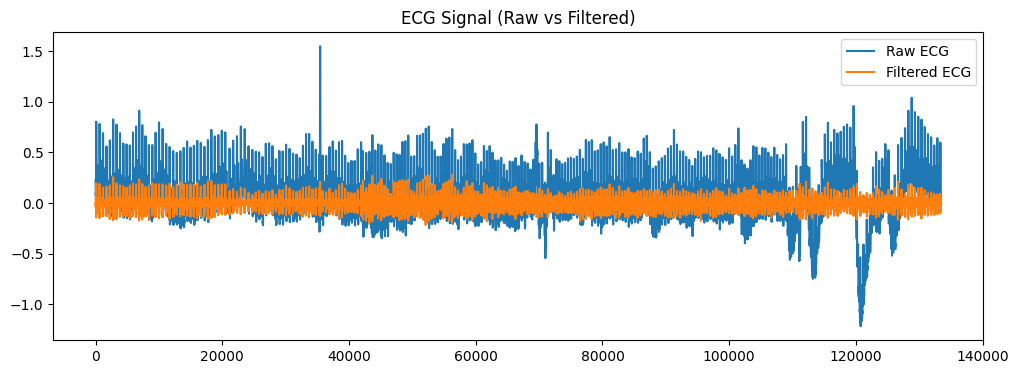

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(ecg_signal, label='Raw ECG')
plt.plot(filtered, label='Filtered ECG')
plt.legend()
plt.title("ECG Signal (Raw vs Filtered)")
plt.show()

In [ ]:
window_len = 50

X_data = []
y_data = []

# Window across signal
for i in range(len(filtered) - window_len):
    segment = filtered[i:i + window_len]
    label = labels[i + window_len // 2]

    X_data.append(segment)
    y_data.append(label)

# Convert to arrays
X_data = np.array(X_data)
y_data = np.array(y_data)

# Normalize inputs
X_data = (X_data - np.mean(X_data)) / np.std(X_data)

print("Shape of dataset:", X_data.shape)

Shape of dataset: (133400, 50)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.2
)

# Created model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train model
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
acc = accuracy_score(y_test, y_pred)
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

missed = fn / (fn + tp)
false_alarm = fp / (fp + tn)

print("Accuracy:", acc)
print("Miss rate:", missed)
print("False alarm rate:", false_alarm)

Accuracy: 0.5058470764617691
Miss rate: 0.4942528735632184
False alarm rate: 0.4916256157635468


In [ ]:
y_full_pred = model.predict(X_data)

In [ ]:
%matplotlib inline

Detected QRS count: 288


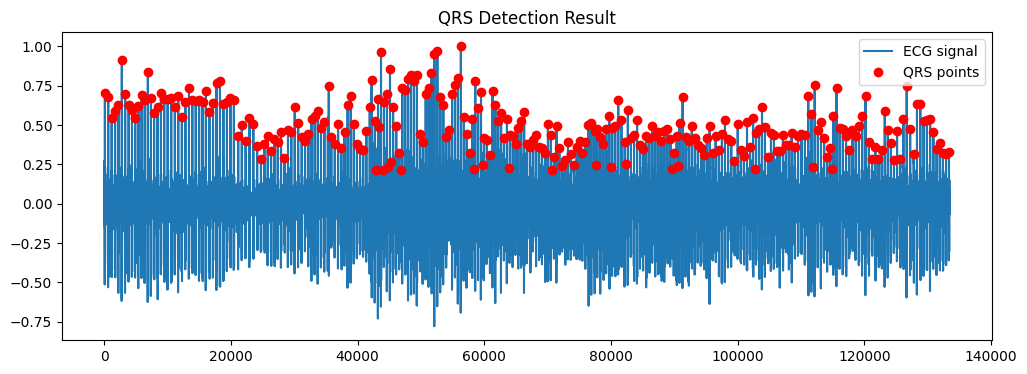

interactive(children=(IntSlider(value=0, description='start', max=131450, step=500), Output()), _dom_classes=(…

<function __main__.show_zoom(start=0)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Normalize the signal
filtered = filtered / np.max(np.abs(filtered))

# Choos threshold automatically
thresh = np.percentile(filtered, 95)

# Find peaks
peaks, _ = find_peaks(filtered, distance=200, height=thresh)

print("Detected QRS count:", len(peaks))

# Plot full signal
plt.figure(figsize=(12,4))
plt.plot(filtered, label='ECG signal')
plt.plot(peaks, filtered[peaks], 'ro', label='QRS points')
plt.title("QRS Detection Result")
plt.legend()
plt.show()

from ipywidgets import interact
import matplotlib.pyplot as plt



def show_zoom(start=0):
    win = 2000
    end = start + win

    plt.figure(figsize=(12,4))
    plt.plot(range(start, end), filtered[start:end])

    # Peaks in this region
    local_peaks = [p for p in peaks if start <= p <= end]
    plt.plot(local_peaks, filtered[local_peaks], 'ro')

    plt.title(f"Zoomed view ({start} to {end})")
    plt.show()

interact(show_zoom, start=(0, len(filtered)-2000, 500))


In [ ]:
# Count detected QRS peaks
num_beats = len(peaks)

print("Estimated number of QRS complexes:", num_beats)

Estimated number of QRS complexes: 385
